# ECM-402 — AI for Signal Processing | Lab 1B

## Problem 1

This notebook is a standalone, dependency-aware extraction from `ECM402_Lab1B_Solution.ipynb`. Only prerequisite code required for this problem is retained.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.linear_model import Lasso
import pandas as pd

np.random.seed(0)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

ECG Signal Generation / Loading

In [6]:
def synthetic_ecg_beat(t, t0, amp_scale=1.0):
    """One PQRST complex, modelled as a sum of Gaussian bumps centred at t0 (the R peak)."""
    def g(mu, sigma, A):
        return A * np.exp(-((t - mu) ** 2) / (2 * sigma ** 2))
    p = g(t0 - 0.20, 0.025, 0.15)
    q = g(t0 - 0.05, 0.008, -0.15)
    r = g(t0, 0.008, 1.20)
    s = g(t0 + 0.05, 0.010, -0.25)
    t_wave = g(t0 + 0.30, 0.040, 0.35)
    return amp_scale * (p + q + r + s + t_wave)


def synthetic_ecg(duration=10.0, fs=360, hr_bpm=75, seed=0):
    """A clean, noise-free-baseline synthetic ECG at a (roughly) fixed heart rate."""
    rng = np.random.default_rng(seed)
    n = int(duration * fs)
    t = np.arange(n) / fs
    rr = 60.0 / hr_bpm
    beat_times = np.arange(0.3, duration, rr)
    beat_times = beat_times + rng.normal(0, 0.01, size=beat_times.shape)  # small HR variability
    s = np.zeros(n)
    for bt in beat_times:
        s += synthetic_ecg_beat(t, bt)
    s += rng.normal(0, 0.008, size=n)  # small measurement noise (part of "clean" signal)
    return s, t, fs, beat_times


def load_ecg(record="100", duration=10.0, seed=0):
    """Try a real MIT-BIH record; fall back to the synthetic generator on any failure."""
    try:
        import wfdb
        rec = wfdb.rdrecord(record, pn_dir="mitdb")
        fs = rec.fs
        n = int(duration * fs)
        s = rec.p_signal[:n, 0].astype(float)
        s = s - np.median(s)
        t = np.arange(n) / fs
        print(f"Loaded REAL MIT-BIH record {record} from PhysioNet (fs={fs} Hz).")
        return s, t, fs, "real"
    except Exception as e:
        s, t, fs, _ = synthetic_ecg(duration=duration, fs=360, hr_bpm=75, seed=seed)
        print(f"[Fallback] Could not reach PhysioNet ({type(e).__name__}: {e}).")
        print("Using synthetic ECG instead (fs=360 Hz, ~75 bpm).")
        return s, t, fs, "synthetic"


s_clean, t, fs, source = load_ecg("100", duration=10.0, seed=0)
print(f"Segment length: {len(s_clean)} samples ({len(s_clean)/fs:.2f} s), source = {source}")



[Fallback] Could not reach PhysioNet (ModuleNotFoundError: No module named 'wfdb').
Using synthetic ECG instead (fs=360 Hz, ~75 bpm).
Segment length: 3600 samples (10.00 s), source = synthetic


Plot Clean ECG

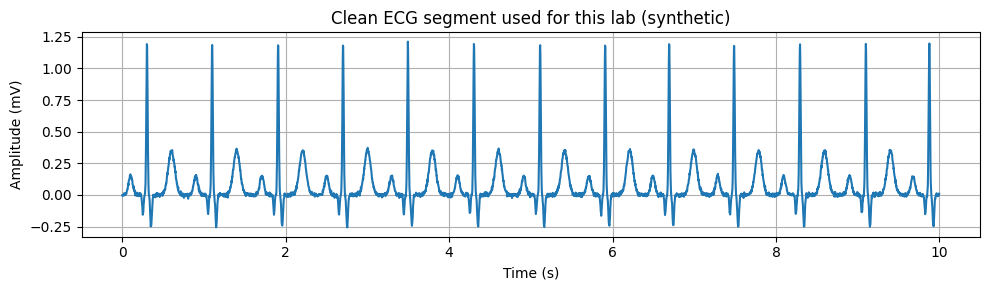

In [7]:
plt.figure(figsize=(10, 3))
plt.plot(t, s_clean)
plt.xlabel("Time (s)"); plt.ylabel("Amplitude (mV)")
plt.title(f"Clean ECG segment used for this lab ({source})")
plt.tight_layout(); plt.show()

Generate Synthetic Baseline Wander

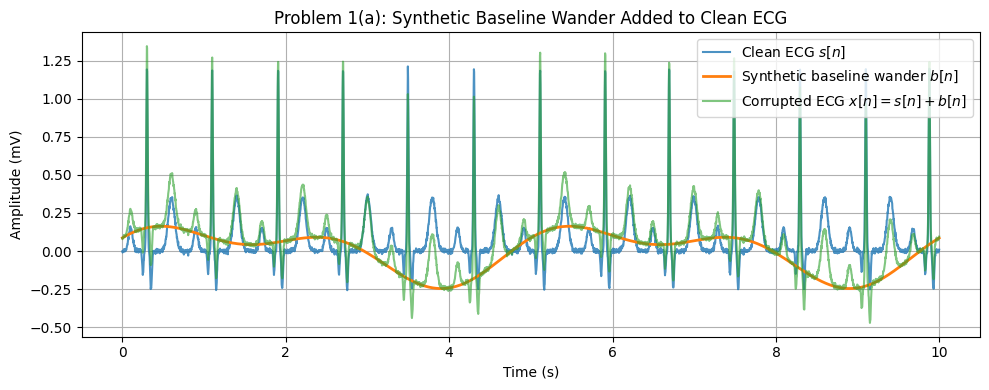

In [8]:

A1, A2 = 0.15, 0.10

f1, f2 = 0.2, 0.4

phi1, phi2 = 0.0, np.pi / 3


# Synthetic baseline wander
b_true = (
    A1 * np.sin(2 * np.pi * f1 * t + phi1)
    +
    A2 * np.sin(2 * np.pi * f2 * t + phi2)
)


# Corrupted ECG
x = s_clean + b_true


plt.figure(figsize=(10, 4))

plt.plot(
    t,
    s_clean,
    label="Clean ECG $s[n]$",
    alpha=0.8
)

plt.plot(
    t,
    b_true,
    label="Synthetic baseline wander $b[n]$",
    linewidth=2
)

plt.plot(
    t,
    x,
    label="Corrupted ECG $x[n] = s[n]+b[n]$",
    alpha=0.6
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

plt.legend(loc="upper right")

plt.title(
    "Problem 1(a): Synthetic Baseline Wander "
    "Added to Clean ECG"
)

plt.tight_layout()
plt.show()

R-Peak Detection and TP-Segment Anchor Extraction

In [9]:

def detect_r_peaks(sig, fs):
    """
    Detect R-peaks using scipy.signal.find_peaks.
    """

    # Minimum distance between consecutive R-peaks
    # Corresponds approximately to a maximum HR of 150 bpm.
    min_distance = int(0.4 * fs)

    # Adaptive amplitude threshold
    height = np.percentile(sig, 85)

    peaks, _ = find_peaks(
        sig,
        height=height,
        distance=min_distance
    )

    return peaks


def extract_anchor_points(
    sig,
    t,
    r_peaks,
    frac_start=0.45,
    frac_end=0.85,
    subsample=3
):
    """
    Extract TP-segment samples between consecutive R-peaks.

    These samples are used as approximate baseline observations.
    """

    anchors_t = []
    anchors_y = []

    for i in range(len(r_peaks) - 1):

        rr_samples = r_peaks[i + 1] - r_peaks[i]

        start = (
            r_peaks[i]
            + int(frac_start * rr_samples)
        )

        end = (
            r_peaks[i]
            + int(frac_end * rr_samples)
        )

        idx = np.arange(
            start,
            end,
            subsample
        )

        # Keep only valid indices
        idx = idx[
            (idx >= 0) &
            (idx < len(sig))
        ]

        anchors_t.extend(t[idx])
        anchors_y.extend(sig[idx])

    return (
        np.array(anchors_t),
        np.array(anchors_y)
    )


# Detect R-peaks
r_peaks = detect_r_peaks(x, fs)


# Extract TP-segment anchor points
t_anchor, y_anchor = extract_anchor_points(
    x,
    t,
    r_peaks
)


print(
    f"Detected {len(r_peaks)} R-peaks "
    f"-> {len(t_anchor)} anchor "
    f"(TP-segment) points."
)

Detected 13 R-peaks -> 465 anchor (TP-segment) points.


Plot R-Peaks and TP-Segment Anchor Points

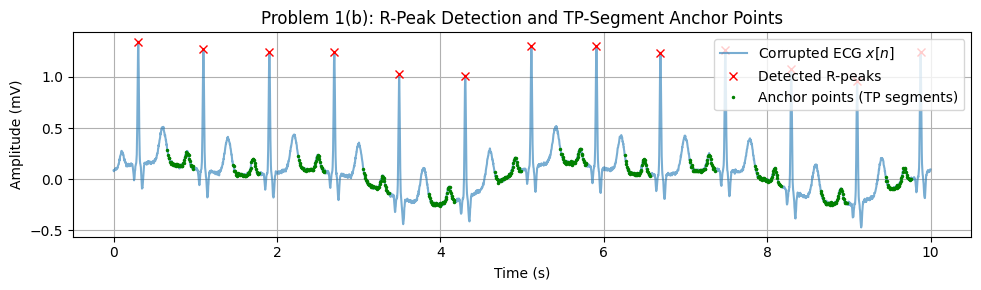

In [10]:


plt.figure(figsize=(10, 3))

plt.plot(
    t,
    x,
    label="Corrupted ECG $x[n]$",
    alpha=0.6
)

plt.plot(
    t[r_peaks],
    x[r_peaks],
    "rx",
    label="Detected R-peaks"
)

plt.plot(
    t_anchor,
    y_anchor,
    ".",
    color="green",
    markersize=3,
    label="Anchor points (TP segments)"
)

plt.legend(loc="upper right")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

plt.title(
    "Problem 1(b): R-Peak Detection and "
    "TP-Segment Anchor Points"
)

plt.tight_layout()
plt.show()

Moving-Average Baseline Estimation

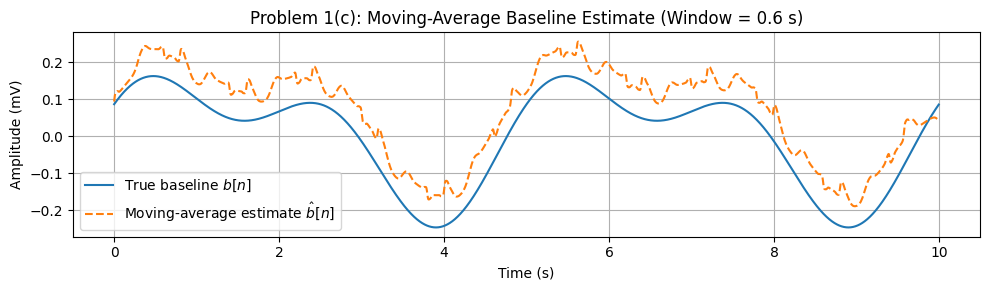

In [11]:


def moving_average_baseline(
    sig,
    fs,
    window_sec=0.6
):
    """
    Estimate the ECG baseline using a moving-average filter.
    """

    win = int(window_sec * fs)

    # Ensure an odd window length
    if win % 2 == 0:
        win += 1

    kernel = np.ones(win) / win

    return np.convolve(
        sig,
        kernel,
        mode="same"
    )


# Estimate baseline
b_hat_mavg = moving_average_baseline(
    x,
    fs,
    window_sec=0.6
)


# Correct the ECG
s_hat_mavg = x - b_hat_mavg


plt.figure(figsize=(10, 3))

plt.plot(
    t,
    b_true,
    label="True baseline $b[n]$"
)

plt.plot(
    t,
    b_hat_mavg,
    label="Moving-average estimate $\\hat b[n]$",
    linestyle="--"
)

plt.legend()

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

plt.title(
    "Problem 1(c): Moving-Average Baseline Estimate "
    "(Window = 0.6 s)"
)

plt.tight_layout()
plt.show()

Evaluation Metrics

In [12]:


def mse(a, b):
    """
    Mean Squared Error.
    """
    return np.mean((a - b) ** 2)


def snr_db(signal, error):
    """
    Signal-to-Noise Ratio in dB.
    """
    return 10 * np.log10(
        np.sum(signal ** 2) /
        np.sum(error ** 2)
    )


def evaluate(
    b_true,
    b_hat,
    s_true,
    s_hat
):
    """
    Evaluate baseline estimation and
    corrected ECG quality.
    """

    return {
        "MSE(b, b_hat)": mse(
            b_true,
            b_hat
        ),

        "BSNR (dB)": snr_db(
            b_true,
            b_true - b_hat
        ),

        "Output SNR (dB)": snr_db(
            s_true,
            s_true - s_hat
        )
    }

In [13]:


# Input SNR before baseline correction
snr_in = snr_db(
    s_clean,
    b_true
)


# Evaluate moving-average method
metrics_mavg = evaluate(
    b_true,
    b_hat_mavg,
    s_clean,
    s_hat_mavg
)


# SNR improvement
metrics_mavg["SNR_imp (dB)"] = (
    metrics_mavg["Output SNR (dB)"]
    - snr_in
)


print(
    f"Input SNR (before any correction): "
    f"{snr_in:.2f} dB\n"
)

print(
    "Moving-average baseline "
    "(Problem 1(c)) evaluation:"
)

for key, value in metrics_mavg.items():

    print(
        f"  {key:18s}: {value:.4f}"
    )

Input SNR (before any correction): 3.92 dB

Moving-average baseline (Problem 1(c)) evaluation:
  MSE(b, b_hat)     : 0.0057
  BSNR (dB)         : 4.5855
  Output SNR (dB)   : 8.5061
  SNR_imp (dB)      : 4.5855
